# Paul15 Hematopoiesis — Palantir + scJDO Drift Field Analysis

Mirrors `Palantir_sample_notebook_driftfield.ipynb` exactly, adapted for the
Paul15 mouse hematopoiesis dataset (2,730 cells, erythroid + neutrophil lineages).

| Step | Tool | What it does |
|------|------|--------------|
| 1 | Scanpy + Palantir | Preprocess: normalize → log → HVG → PCA → diffusion maps → UMAP |
| 2 | Palantir | Pseudotime + branch probabilities → `select_branch_cells` |
| 3 | scJDO | Branch-separated drift field — Ery and Neu independently |
| 4 | scJDO | Per-branch: drift field, sensitivity, archetypes, coordination |
| 5 | scJDO | Instability genes per lineage |
| 6 | scJDO | Regulatory network per lineage |
| 7 | scJDO | Cross-lineage comparison |

**Dataset:** Paul15 — 2,730 murine bone marrow cells, built into Scanpy  
**Lineages:** Erythroid (Ery) and Neutrophil (Neu)

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc
import palantir
import scjdo as sjd
from scjdo.tl._drift import _pseudotime_velocity

OUTDIR = 'results/07_paul15_palantir/'
os.makedirs(OUTDIR, exist_ok=True)

# ── Paul15 Palantir config ─────────────────────────────────────────────────
N_WAYPOINTS  = 500
N_HVG        = 1500   # same as Palantir sample notebook
N_PCS        = 50

# ── scJDO config ─────────────────────────────────────────────────────────
N_ARCHETYPES = 5
N_EPOCHS     = 5000   # increase to 50000 on GPU for publication quality
SEED         = 42

# Branch display colors
BRANCH_COLORS = {'Ery': '#E63946', 'Neu': '#457B9D'}
ARCH_COLORS   = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#8338EC']

print(f'scjdo  v{sjd.__version__}')
print(f'palantir v{palantir.__version__}')

scjdo  v0.3.0
palantir v1.4.4


## Step 1 — Load Paul15 and preprocess

Mirrors the Palantir sample notebook preprocessing pipeline:
`normalize_per_cell` → `log_transform` → HVG → PCA → diffusion maps → UMAP

Loaded Paul15: 2730 cells x 3451 genes
Cell types: ['10GMP', '11DC', '12Baso', '13Baso', '14Mo', '15Mo', '16Neu', '17Neu', '18Eos', '19Lymph', '1Ery', '2Ery', '3Ery', '4Ery', '5Ery', '6Ery', '7MEP', '8Mk', '9GMP']
PCA done — varm["PCs"] shape: (3451, 50)


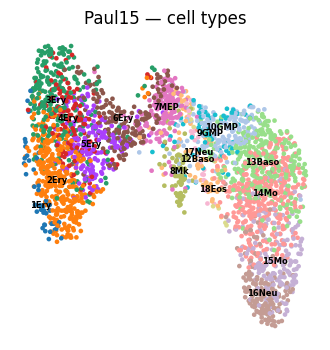

<Figure size 400x400 with 0 Axes>

Preprocessing complete.


In [16]:
# Load Paul15 (built into Scanpy — no download needed)
ad = sc.datasets.paul15()
print(f'Loaded Paul15: {ad.n_obs} cells x {ad.n_vars} genes')
print(f'Cell types: {sorted(ad.obs["paul15_clusters"].unique().tolist())}')

REMOVE_CLUSTERS = ['19Lymph', '11DC']

keep_mask = ~ad.obs['paul15_clusters'].isin(REMOVE_CLUSTERS)

ad = ad[keep_mask].copy()

# Identify ribosomal genes
ribo_mask = ad.var_names.str.startswith(("Rps", "Rpl", "RPS", "RPL"))

# Remove them
ad = ad[:, ~ribo_mask].copy()


# Store raw counts before normalization (needed for MAGIC + scVI if used)
ad.layers['raw_counts'] = ad.X.copy()

# Normalize + log (same pipeline as Palantir sample notebook)
sc.pp.normalize_per_cell(ad)
palantir.preprocess.log_transform(ad)   # log2(x + 0.1), same as sample notebook

# HVG + PCA
sc.pp.highly_variable_genes(ad, n_top_genes=N_HVG, flavor='cell_ranger')
sc.pp.pca(ad, n_comps=N_PCS)
print(f'PCA done — varm["PCs"] shape: {ad.varm["PCs"].shape}')

# Diffusion maps (Palantir method — on PCA, same as sample notebook)
dm_res  = palantir.utils.run_diffusion_maps(ad, n_components=5)
ms_data = palantir.utils.determine_multiscale_space(ad)

# UMAP
sc.pp.neighbors(ad, n_pcs=N_PCS)
sc.tl.umap(ad)

# MAGIC imputation (for gene visualization)
palantir.utils.run_magic_imputation(ad)

# Visualize cell types on UMAP
sc.pl.umap(ad, color='paul15_clusters', legend_loc='on data',
           legend_fontsize=6, title='Paul15 — cell types', frameon=False)
plt.savefig(OUTDIR + 'umap_celltypes.pdf', dpi=150, bbox_inches='tight')
plt.show()

print('Preprocessing complete.')

## Step 2 — Run Palantir

Same approach as Palantir sample notebook:
1. Define terminal state cells (one representative per lineage)
2. Highlight on UMAP
3. Run Palantir with explicit terminal states
4. Call `select_branch_cells` for proper branch assignment

Start / progenitor cell: W38916 (cluster: 7MEP)
Terminal Ery: W38233 (cluster: 3Ery)
Terminal Neu: W37424 (cluster: 15Mo)
terminal_states passed to Palantir: ['W38233', 'W37424']


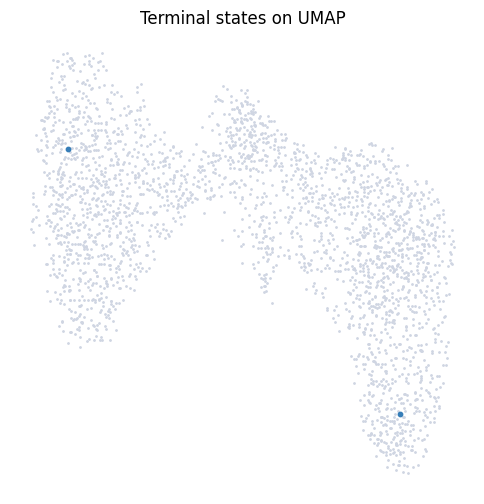

In [17]:
# ── Define progenitor and terminal clusters ───────────────────────────────

PROGENITOR_CLUSTER = '7MEP'

TERMINAL_CLUSTERS = {
    'Ery': '3Ery',
    'Neu': '15Mo'
}


def representative_cell(adata, cluster, cluster_key='paul15_clusters', rep='X_pca'):
    """
    Return the cell in `cluster` closest to that cluster's centroid
    in the chosen representation.
    """
    mask = (adata.obs[cluster_key] == cluster).values

    if mask.sum() == 0:
        raise ValueError(f"No cells found for cluster: {cluster}")

    X = adata.obsm[rep]
    centroid = X[mask].mean(axis=0)
    dists = ((X[mask] - centroid) ** 2).sum(axis=1)

    return adata.obs_names[mask][dists.argmin()]


start_cell = representative_cell(ad, PROGENITOR_CLUSTER)

terminal_cells = {
    name: representative_cell(ad, cluster)
    for name, cluster in TERMINAL_CLUSTERS.items()
}

terminal_states = list(terminal_cells.values())

print(
    f'Start / progenitor cell: {start_cell} '
    f'(cluster: {ad.obs.loc[start_cell, "paul15_clusters"]})'
)

for branch_name, cell_id in terminal_cells.items():
    print(
        f'Terminal {branch_name}: {cell_id} '
        f'(cluster: {ad.obs.loc[cell_id, "paul15_clusters"]})'
    )

print("terminal_states passed to Palantir:", terminal_states)

# Highlight on UMAP (mirrors sample notebook)
palantir.plot.highlight_cells_on_umap(ad, terminal_states)
plt.title('Terminal states on UMAP')
plt.savefig(OUTDIR + 'terminal_states.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Run Palantir ──────────────────────────────────────────────────────────
# Identical call structure to Palantir sample notebook
pr_res = palantir.core.run_palantir(
    ad,
    start_cell,
    num_waypoints   = N_WAYPOINTS,
    terminal_states = terminal_states,
)
# Stored automatically:
#   ad.obs['palantir_pseudotime']           [0, 1]
#   ad.obs['palantir_entropy']
#   ad.obsm['palantir_fate_probabilities']  (Ery, Neu columns)

print(f'Pseudotime range: [{ad.obs["palantir_pseudotime"].min():.3f}, '
      f'{ad.obs["palantir_pseudotime"].max():.3f}]')
print(f'Fate prob columns: {list(ad.obsm["palantir_fate_probabilities"].columns)}')

# Normalize pseudotime to [0,1] for scJDO
pt = ad.obs['palantir_pseudotime'].values.astype('float32')
pt = (pt - pt.min()) / (pt.max() - pt.min() + 1e-8)
ad.obs['pseudotime'] = pt

Sampling and flocking waypoints...
Time for determining waypoints: 6.74128532409668e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.00908207098642985 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Pseudotime range: [0.000, 1.000]
Fate prob columns: ['W37424', 'W38233']


Branch cell counts:
  W37424: 1455 cells (55%)
  W38233: 1169 cells (44%)


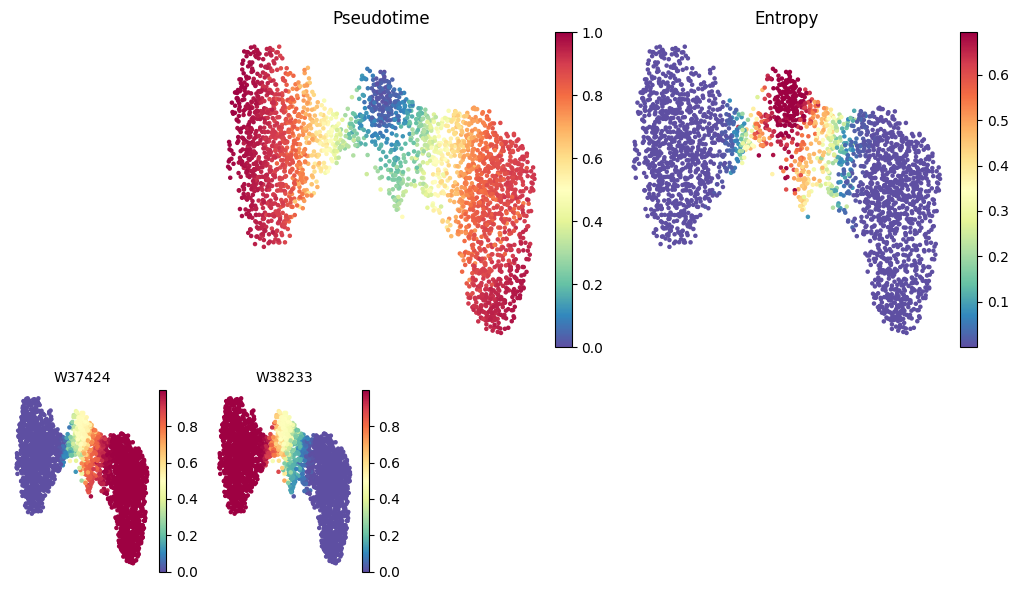

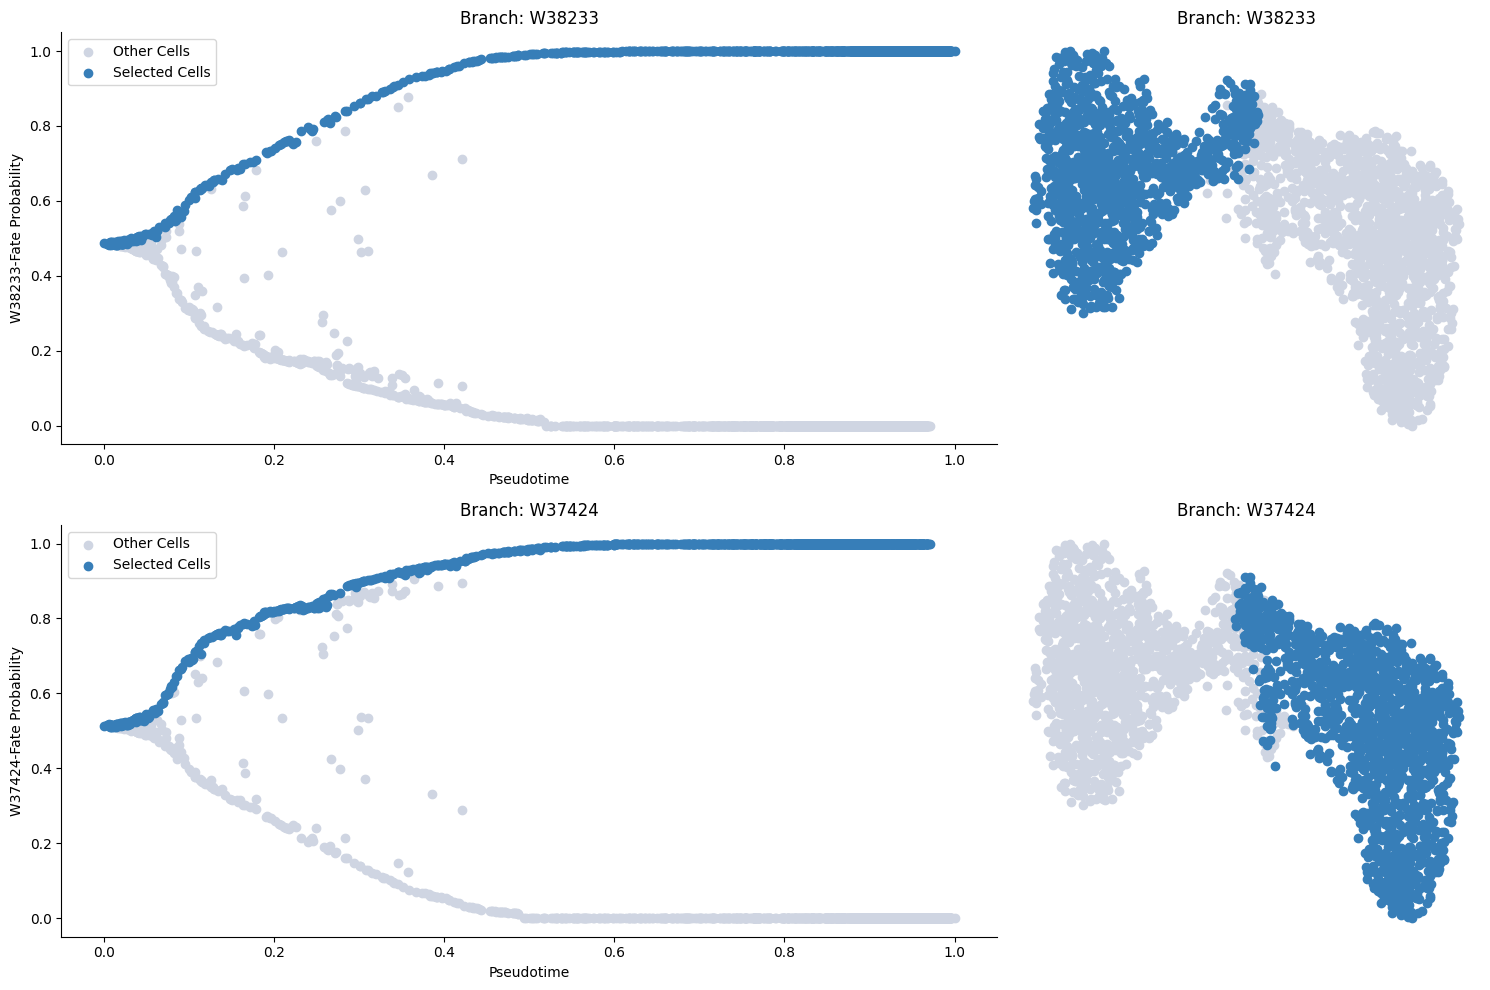

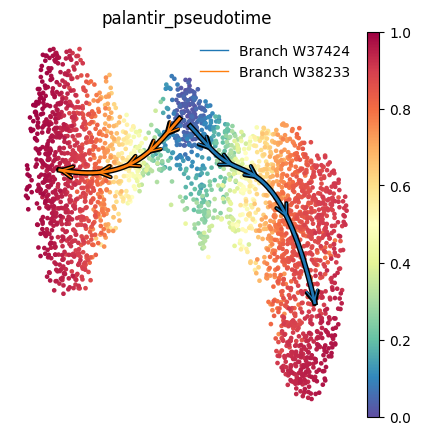

[2026-05-22 06:00:22,326] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,455) and rank = 1.0.
[2026-05-22 06:00:22,327] [INFO    ] Using covariance function Matern52(ls=1.083743691444397).
[2026-05-22 06:00:22,327] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-22 06:00:22,336] [INFO    ] Sigma interpreted as element-wise standard deviation.


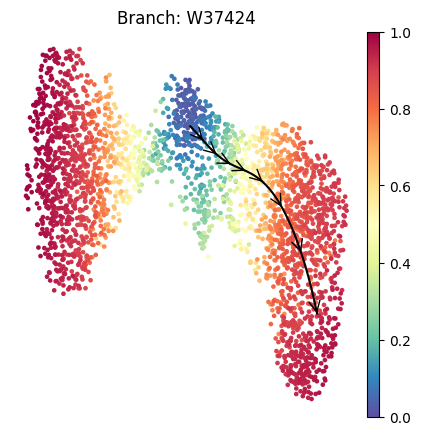

[2026-05-22 06:00:22,484] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,169) and rank = 1.0.
[2026-05-22 06:00:22,484] [INFO    ] Using covariance function Matern52(ls=1.083743691444397).
[2026-05-22 06:00:22,485] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-22 06:00:22,492] [INFO    ] Sigma interpreted as element-wise standard deviation.


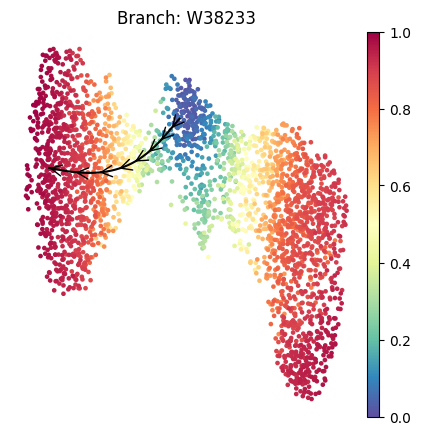

<Figure size 400x400 with 0 Axes>

In [19]:
# ── select_branch_cells — Palantir's proper branch assignment ─────────────
# Creates boolean masks: each column marks cells on that lineage path.
# Progenitors appear in ALL branches (biologically correct).
palantir.presults.select_branch_cells(
    ad,
    pseudo_time_key = 'palantir_pseudotime',
    fate_prob_key   = 'palantir_fate_probabilities',
    q=0.01, eps=0.01,
    masks_key       = 'branch_masks',
    save_as_df      = True,
)
masks_df = ad.obsm['branch_masks']
print('Branch cell counts:')
for col in masks_df.columns:
    n = masks_df[col].sum()
    print(f'  {col}: {n} cells ({100*n/len(ad):.0f}%)')

# ── Palantir visualizations (mirrors sample notebook) ─────────────────────
palantir.plot.plot_palantir_results(ad, s=5)
plt.savefig(OUTDIR + 'palantir_results.pdf', dpi=150, bbox_inches='tight')
plt.show()

palantir.plot.plot_branch_selection(ad)
plt.savefig(OUTDIR + 'branch_selection.pdf', dpi=150, bbox_inches='tight')
plt.show()

palantir.plot.plot_trajectories(ad, pseudotime_interval=(0, 0.95))
plt.savefig(OUTDIR + 'trajectories.pdf', dpi=150, bbox_inches='tight')
plt.show()

# Per-branch trajectory (mirrors sample notebook plot_trajectory calls)
for branch in ad.obsm['branch_masks'].columns:
    palantir.plot.plot_trajectory(ad, branch,
                                   cell_color='palantir_pseudotime', n_arrows=8)
    plt.savefig(OUTDIR + f'trajectory_{branch}.pdf', dpi=150, bbox_inches='tight')
    plt.show()

# Gene expression on UMAP (mirrors sample notebook CD34/MPO/GATA1/IRF8)
#sc.pl.umap(ad, layer='MAGIC_imputed_data',
#           color=['Gata1', 'Mpo', 'Elane', 'Spi1'],
#           frameon=False)
plt.savefig(OUTDIR + 'gene_expression_umap.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — scJDO branch-separated drift field

Runs scJDO independently on each Palantir branch. Branch boolean masks from
`select_branch_cells` ensure progenitors contribute to both lineages (correct).

In [20]:
# ── Branch-separated scJDO with biology-informed velocity bias ──────────
#
# bias_strength = 0.0  → pure pseudotime gradient (no prior knowledge used)
# bias_strength = 1.0  → equal weight: pseudotime gradient + terminal pull
# bias_strength = 2–5  → strong pull toward known terminal states
#
# The terminal pull scales by pseudotime[i] so progenitors (pt≈0) are barely
# affected while committed cells get a strong pull toward their fate.
# The progenitor centroid is used to project the pull onto the known
# progenitor→terminal axis, suppressing lateral drift.

PROGENITOR_CLUSTER = '7MEP'
TERMINAL_CLUSTERS  = {
    'Ery': '3Ery',   # late erythroid
    'Neu': '15Mo',   # late myeloid / monocyte
}
BIAS_STRENGTH = 5   # tune: 0 = no bias, 1–2 = recommended, 5 = strong

branch_models = sjd.tl.fit_drift_branches(
    ad,
    branch_key         = 'branch_masks',
    branch_names       = list(ad.obsm['branch_masks'].columns),
    time_key           = 'pseudotime',
    # Biology-informed bias — known progenitor → terminal direction
    groupby            = 'paul15_clusters',
    progenitor_cluster = PROGENITOR_CLUSTER,
    terminal_clusters  = TERMINAL_CLUSTERS,
    bias_strength      = BIAS_STRENGTH,
    n_archetypes       = N_ARCHETYPES,
    n_epochs           = N_EPOCHS,
    vel_scale          = 2.0,
    seed               = SEED,
)

print('\nBranch results:')
for name in branch_models:
    key  = f'scjdo_{name}'
    r2   = ad.uns[key]['r2']
    n    = ad.uns[key]['n_cells']
    peak = ad.uns[key]['t_centers'][np.argmax(ad.uns[key]['max_real_eig'])]
    print(f'  {name}: {n} cells | R2={r2:.3f} | '
          f'peak sensitivity t={peak:.3f}')

[bias] Progenitor '7MEP': 167 cells, centroid computed in X_pca

Branch: W37424  (1455 cells)
[fit_drift] Using representation: X_pca (latent=pca)
Computing pseudotime-gradient velocity prior...
DriftField: 894,692 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 100.2777
Computing Jacobian tensor...


Jacobians:   0%|          | 0/100 [00:00<?, ?it/s]

Running archetype decomposition (semi-NMF)...
Done. R²=0.993 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=0.993  stored in adata.uns['scjdo_W37424']

Branch: W38233  (1169 cells)
[fit_drift] Using representation: X_pca (latent=pca)
Computing pseudotime-gradient velocity prior...
DriftField: 894,692 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 99.5823
Computing Jacobian tensor...


Jacobians:   0%|          | 0/100 [00:00<?, ?it/s]

Running archetype decomposition (semi-NMF)...
Done. R²=0.983 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=0.983  stored in adata.uns['scjdo_W38233']

Branch results stored: ['scjdo_W37424', 'scjdo_W38233']

Branch results:
  W37424: 1455 cells | R2=0.993 | peak sensitivity t=0.111
  W38233: 1169 cells | R2=0.983 | peak sensitivity t=0.082


## Step 4 — Per-branch 4-panel figures


=== W37424 lineage (1455 cells) ===


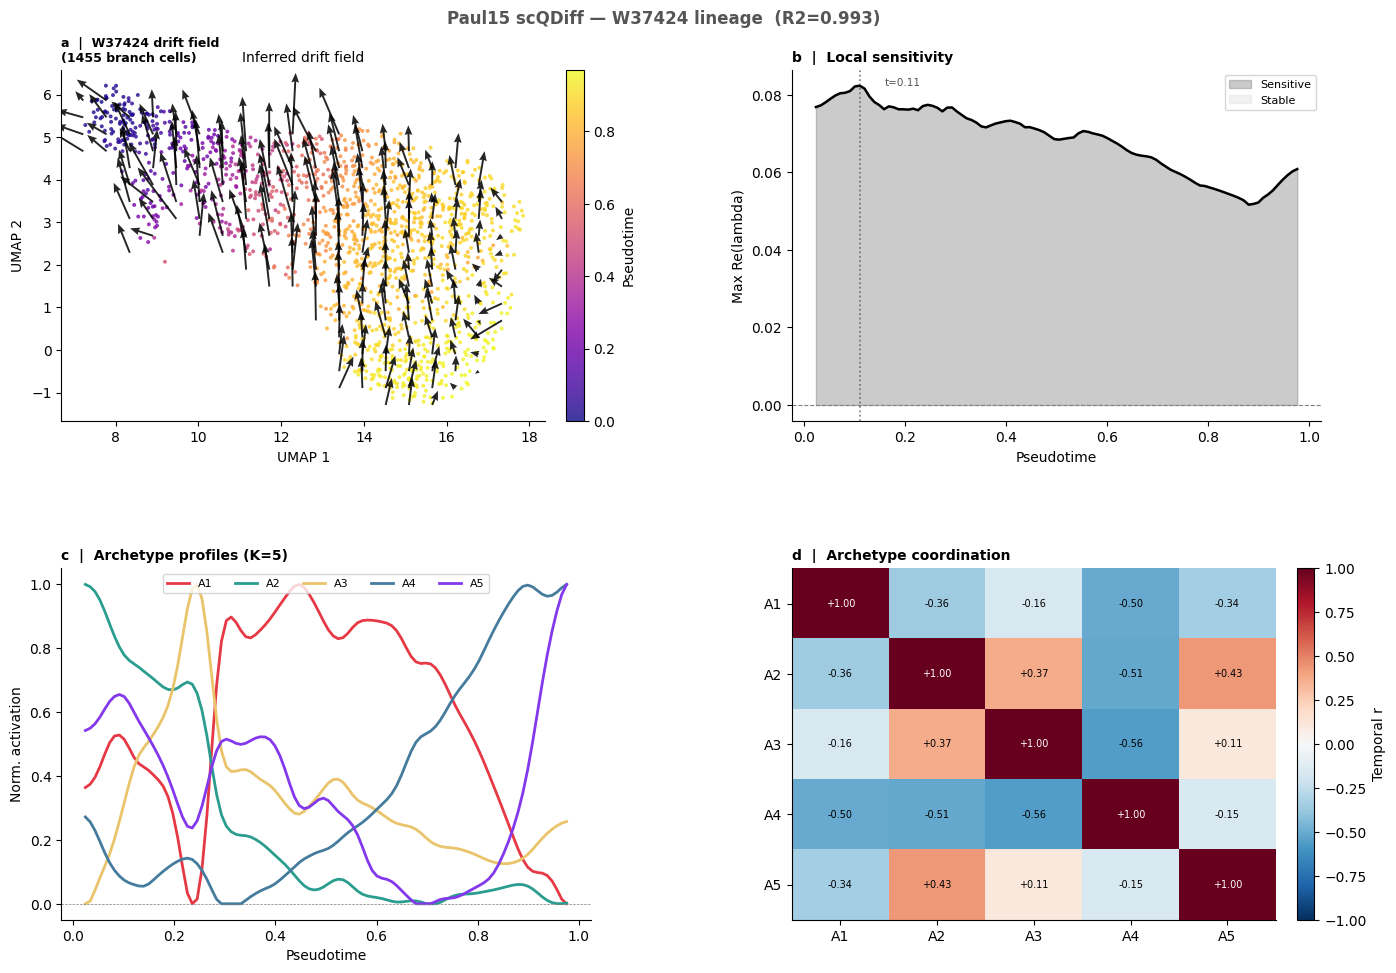

Saved: results/07_paul15_palantir/figure_W37424.pdf

=== W38233 lineage (1169 cells) ===


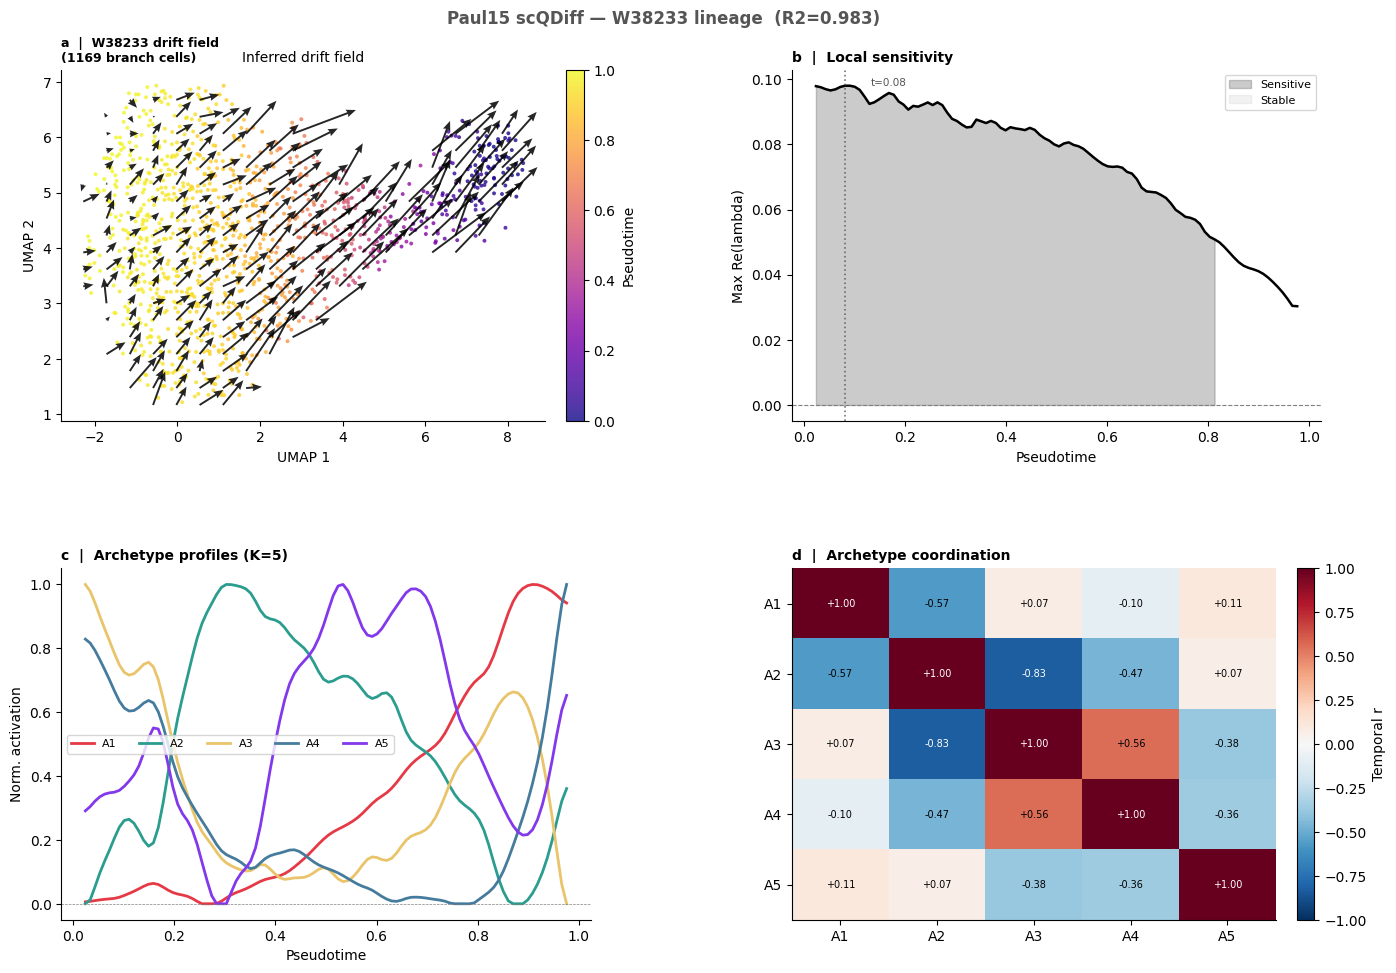

Saved: results/07_paul15_palantir/figure_W38233.pdf


In [21]:
for branch in branch_models:
    key      = f'scjdo_{branch}'
    cell_idx = np.array(ad.uns[key]['branch_cells'])
    print(f'\n=== {branch} lineage ({len(cell_idx)} cells) ===')

    ad_b = ad[cell_idx].copy()
    ad_b.uns[key] = ad.uns[key]

    # Branch-specific velocity — arrows radiate along THIS lineage only
    X_b  = ad_b.obsm['X_pca'].astype('float32')
    pt_b = ad_b.obs['pseudotime'].values.astype('float32')
    ad_b.obsm['X_velocity_pseudo'] = _pseudotime_velocity(X_b, pt_b, k=15)
    if 'X_drift' in ad.uns[key]:
        ad_b.obsm['X_drift'] = ad.uns[key]['X_drift']

    res  = ad.uns[key]
    t    = res['t_centers']
    eig  = res['max_real_eig']
    act  = res['act_norm']
    corr = res['corr_mat']
    K    = act.shape[1]
    bcol = BRANCH_COLORS.get(branch, '#555')

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.38,
                            left=0.07, right=0.97, top=0.92, bottom=0.07)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, 0])
    ax_d = fig.add_subplot(gs[1, 1])

    # a — drift field (UMAP, branch-specific velocity)
    plot_basis = 'X_umap' if 'X_umap' in ad_b.obsm else 'X_pca'
    sjd.pl.drift_field(ad_b, key=key, basis=plot_basis,
                        color='pseudotime', velocity_key='X_velocity_pseudo',
                        stream=False, n_grid=16, min_cells=2, ax=ax_a)
    ax_a.set_title(f'a  |  {branch} drift field\n'
                   f'({len(cell_idx)} branch cells)',
                   fontweight='bold', loc='left', fontsize=9)

    # b — local sensitivity
    ax_b.plot(t, eig, color='black', lw=1.8)
    ax_b.fill_between(t, eig, 0, where=eig>=0.05, alpha=0.30, color=bcol, label='Sensitive')
    ax_b.fill_between(t, eig, 0, where=eig<=-0.05, alpha=0.15, color='#aaa', label='Stable')
    ax_b.axhline(0, color='gray', lw=0.8, ls='--')
    peak_t = t[np.argmax(eig)]
    ax_b.axvline(peak_t, color=bcol, lw=1.2, ls=':', alpha=0.8)
    ax_b.annotate(f't={peak_t:.2f}', xy=(peak_t, eig.max()),
                  xytext=(peak_t+0.05, eig.max()), fontsize=7.5, color=bcol)
    ax_b.set_xlabel('Pseudotime'); ax_b.set_ylabel('Max Re(lambda)')
    ax_b.set_title('b  |  Local sensitivity', fontweight='bold', loc='left', fontsize=10)
    ax_b.legend(fontsize=8)

    # c — archetype activation profiles
    for k in range(K):
        ax_c.plot(t, act[:, k], color=ARCH_COLORS[k], lw=2, label=f'A{k+1}')
    ax_c.axhline(0, color='gray', lw=0.5, ls='--')
    ax_c.set_xlabel('Pseudotime'); ax_c.set_ylabel('Norm. activation')
    ax_c.set_title(f'c  |  Archetype profiles (K={K})',
                   fontweight='bold', loc='left', fontsize=10)
    ax_c.legend(ncol=K, fontsize=8)

    # d — coordination heatmap
    im = ax_d.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax_d.set_xticks(range(K)); ax_d.set_xticklabels([f'A{k+1}' for k in range(K)])
    ax_d.set_yticks(range(K)); ax_d.set_yticklabels([f'A{k+1}' for k in range(K)])
    for i in range(K):
        for j in range(K):
            ax_d.text(j, i, f'{corr[i,j]:+.2f}', ha='center', va='center',
                      fontsize=7, color='white' if abs(corr[i,j])>0.6 else 'black')
    plt.colorbar(im, ax=ax_d, label='Temporal r', fraction=0.046, pad=0.04)
    ax_d.set_title('d  |  Archetype coordination',
                   fontweight='bold', loc='left', fontsize=10)

    fig.suptitle(f'Paul15 scJDO — {branch} lineage  (R2={res["r2"]:.3f})',
                 fontsize=12, fontweight='bold', color=bcol)
    save_path = OUTDIR + f'figure_{branch}.pdf'
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved: {save_path}')

## Step 5 — Gene expression trends along branches

Mirrors Palantir sample notebook — marker genes across pseudotime per lineage.

W37424
[2026-05-22 06:13:27,609] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,455) and rank = 1.0.
[2026-05-22 06:13:27,610] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-22 06:13:27,822] [INFO    ] Sigma interpreted as element-wise standard deviation.
W38233
[2026-05-22 06:13:27,917] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,169) and rank = 1.0.
[2026-05-22 06:13:27,918] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-22 06:13:28,117] [INFO    ] Sigma interpreted as element-wise standard deviation.


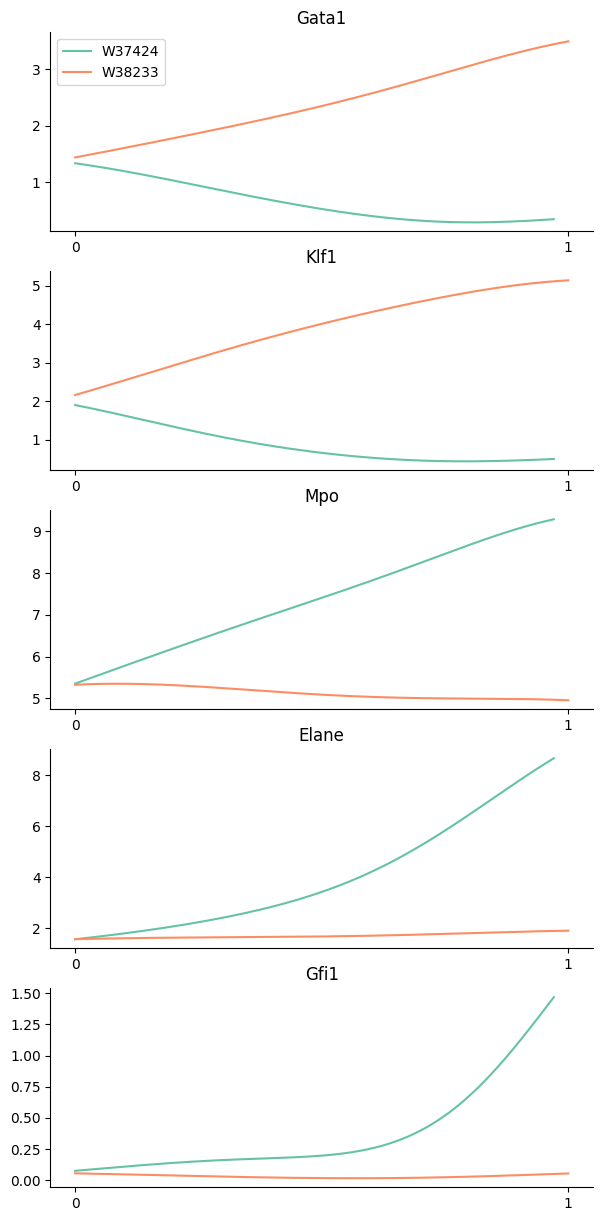

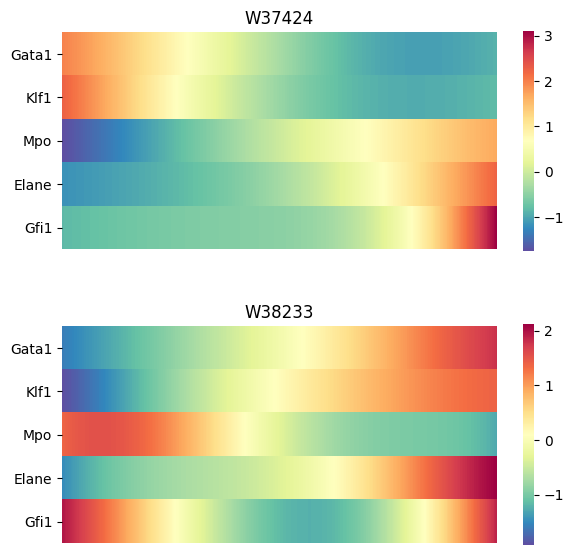

In [22]:
# Gene expression trends (mirrors sample notebook)
gene_trends = palantir.presults.compute_gene_trends(
    ad,
    expression_key='MAGIC_imputed_data',
)

# Key hematopoiesis marker genes
markers = ['Gata1', 'Klf1', 'Mpo', 'Elane', 'Spi1', 'Gfi1']
genes_present = [g for g in markers if g in ad.var_names]

palantir.plot.plot_gene_trends(ad, genes_present)
plt.savefig(OUTDIR + 'gene_trends.pdf', dpi=150, bbox_inches='tight')
plt.show()

palantir.plot.plot_gene_trend_heatmaps(ad, genes_present)
plt.savefig(OUTDIR + 'gene_trend_heatmaps.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Instability genes per lineage


W37424 lineage — instability genes


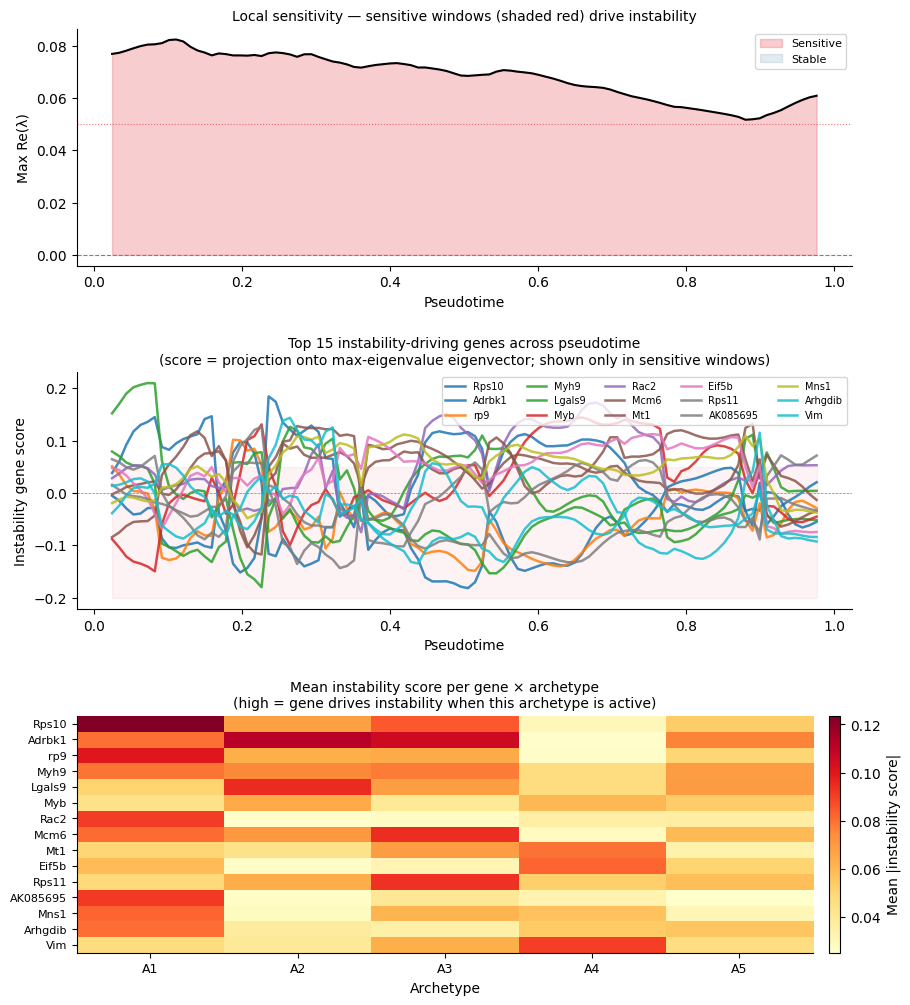

 rank     gene  mean_instability_score  peak_pseudotime primary_archetype
    1    Rps10                  0.0781            0.505                A1
    2   Adrbk1                  0.0727            0.236                A3
    3      rp9                  0.0665            0.514                A1
    4     Myh9                  0.0663            0.543                A1
    5   Lgals9                  0.0623            0.072                A2
    6      Myb                  0.0620            0.082                A2
    7     Rac2                  0.0611            0.678                A1
    8     Mcm6                  0.0603            0.889                A4
    9      Mt1                  0.0595            0.793                A4
   10    Eif5b                  0.0594            0.755                A4
   11    Rps11                  0.0580            0.332                A1
   12 AK085695                  0.0573            0.649                A1
   13     Mns1                  0.0573

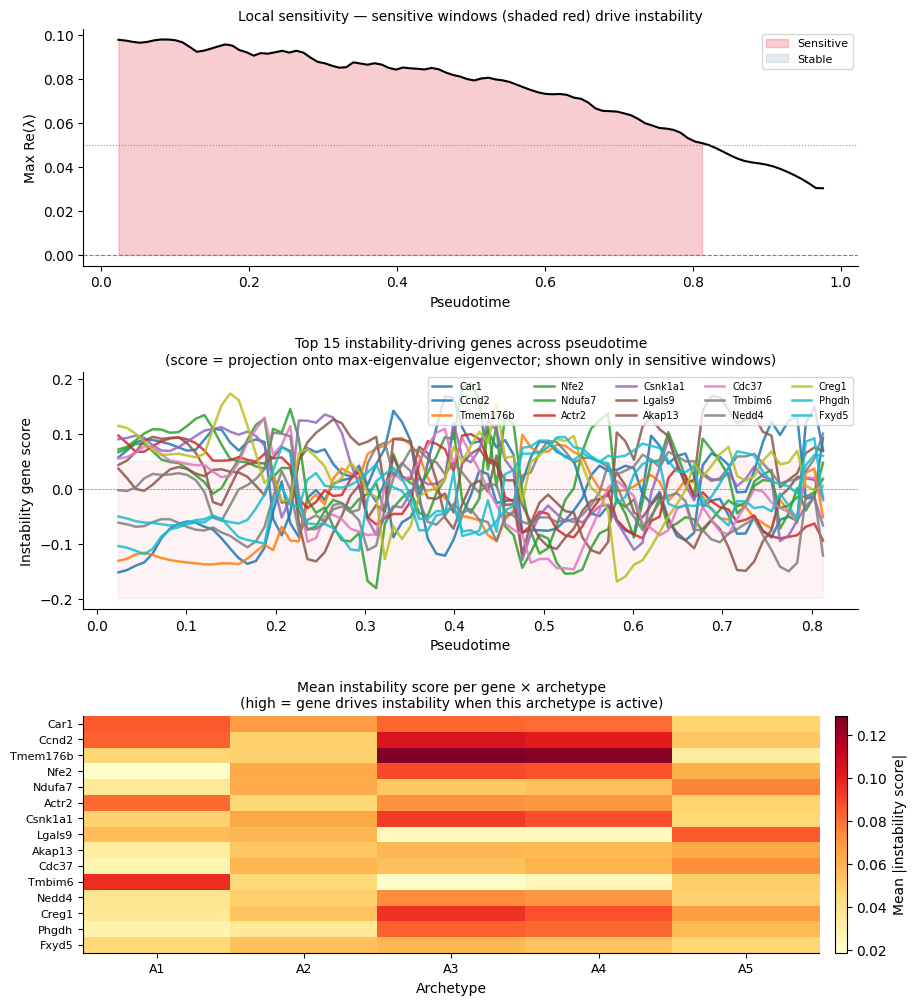

 rank     gene  mean_instability_score  peak_pseudotime primary_archetype
    1     Car1                  0.0721            0.389                A2
    2    Ccnd2                  0.0658            0.024                A3
    3 Tmem176b                  0.0656            0.130                A3
    4     Nfe2                  0.0615            0.312                A2
    5   Ndufa7                  0.0610            0.418                A2
    6    Actr2                  0.0568            0.418                A2
    7  Csnk1a1                  0.0567            0.255                A2
    8   Lgals9                  0.0566            0.688                A5
    9   Akap13                  0.0546            0.726                A5
   10    Cdc37                  0.0545            0.534                A5
   11   Tmbim6                  0.0544            0.774                A1
   12    Nedd4                  0.0542            0.168                A3
   13    Creg1                  0.0535

In [23]:
gene_tables = {}

for branch in branch_models:
    key      = f'scjdo_{branch}'
    cell_idx = np.array(ad.uns[key]['branch_cells'])
    ad_b     = ad[cell_idx].copy()
    ad_b.uns[key]    = ad.uns[key]
    ad_b.varm['PCs'] = ad.varm['PCs']

    print(f'\n{"="*55}')
    print(f'{branch} lineage — instability genes')
    print(f'{"="*55}')
    table = sjd.pl.instability_genes(
        ad_b, key=key, n_genes=15,
        save=OUTDIR + f'instability_genes_{branch}.pdf',
    )
    gene_tables[branch] = table
    table.to_csv(OUTDIR + f'instability_genes_{branch}.csv', index=False)

## Step 7 — Regulatory network per lineage

[network] TRRUST v2 loaded — 7,057 edges


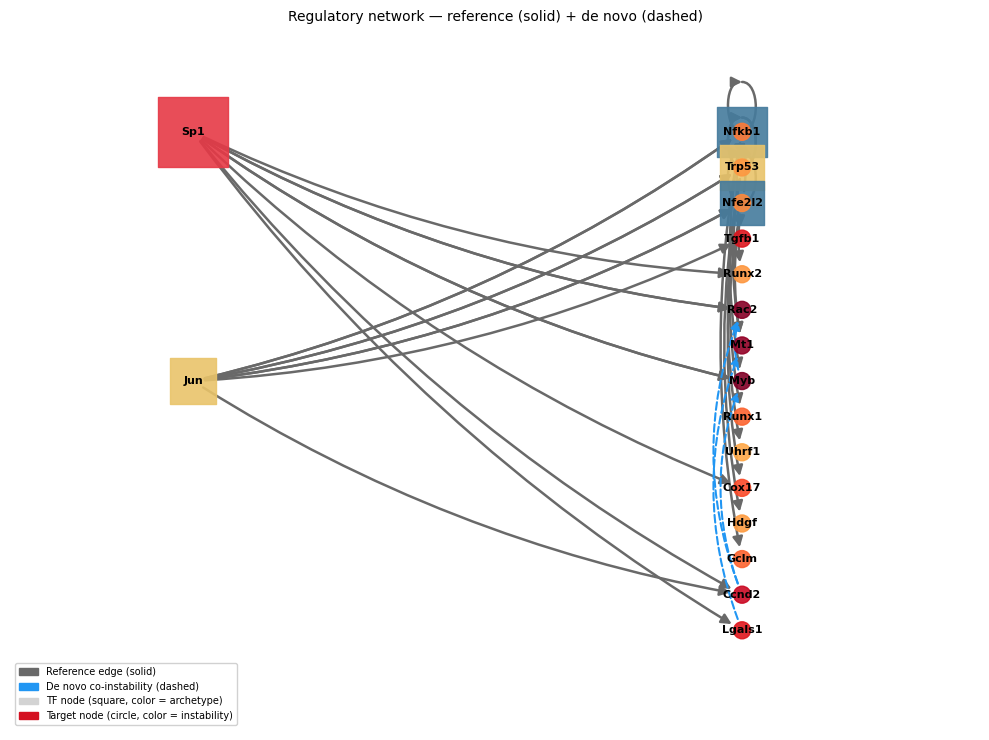

W37424 top 5: ['Sp1', 'Nfkb1', 'Jun', 'Trp53', 'Nfe2l2']
[network] TRRUST v2 loaded — 7,057 edges


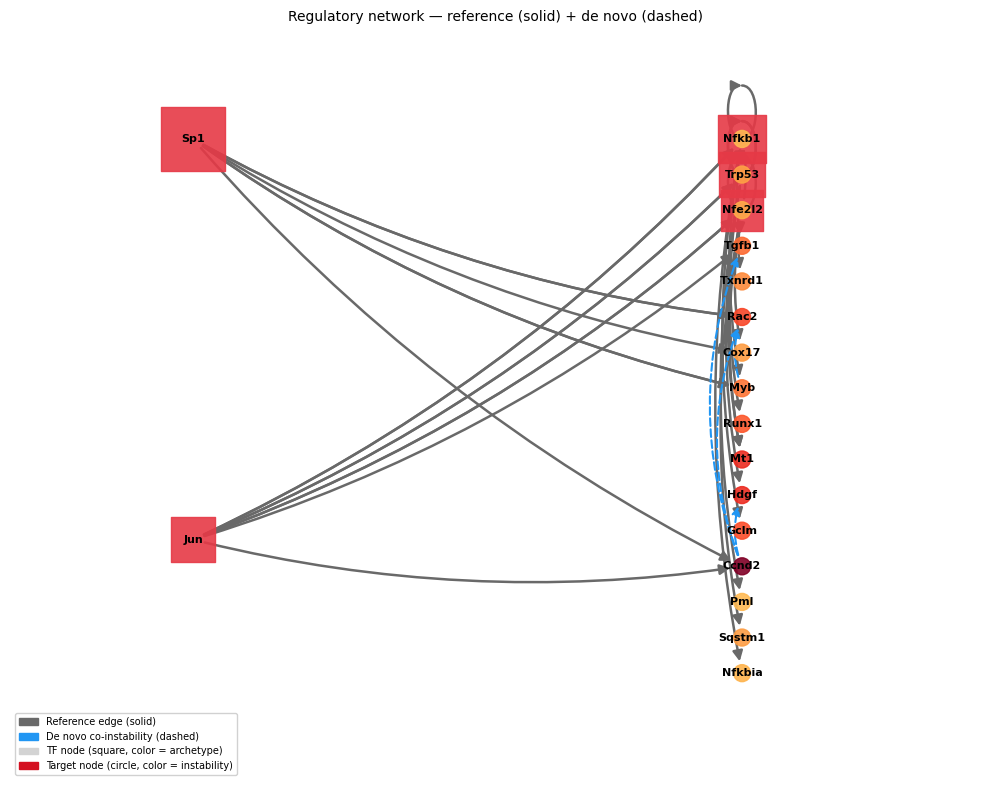

W38233 top 5: ['Sp1', 'Nfkb1', 'Trp53', 'Jun', 'Nfe2l2']


In [24]:
reg_tables = {}

for branch in branch_models:
    key      = f'scjdo_{branch}'
    reg_key  = f'scjdo_regulators_{branch}'
    cell_idx = np.array(ad.uns[key]['branch_cells'])
    ad_b     = ad[cell_idx].copy()
    ad_b.uns[key]    = ad.uns[key]
    ad_b.varm['PCs'] = ad.varm['PCs']

    df_reg = sjd.tl.infer_regulators(
        ad_b, key=key,
        organism  = 'mouse',
        n_top     = 15,
        key_added = reg_key,
        verbose   = False,
    )
    reg_tables[branch] = df_reg
    df_reg.to_csv(OUTDIR + f'regulators_{branch}.csv', index=False)

    sjd.pl.regulator_network(
        ad_b, key=reg_key, scjdo_key=key,
        n_tfs=5, n_targets=5,
        save=OUTDIR + f'regulator_network_{branch}.pdf',
    )
    print(f'{branch} top 5: {df_reg["regulator"].head(5).tolist()}')

## Step 8 — Cross-lineage comparison (Ery vs Neu)

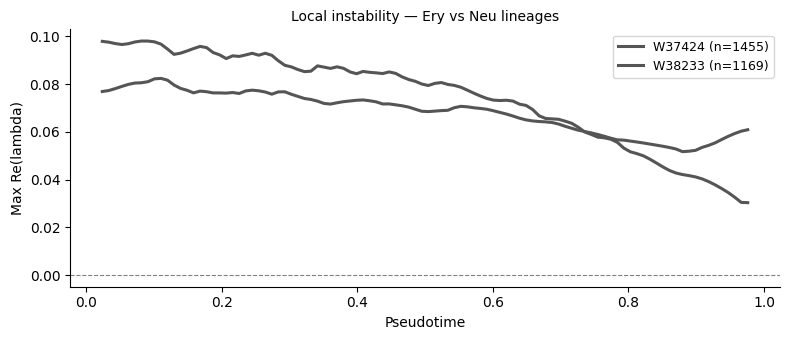

Instability gene comparison:
  W37424-specific (14): AK085695, Adrbk1, Arhgdib, Eif5b, Mcm6, Mns1, Mt1, Myb
  W38233-specific (14): Actr2, Akap13, Car1, Ccnd2, Cdc37, Creg1, Csnk1a1, Fxyd5
  Shared      (1): Lgals9

Regulator comparison:
  W37424-specific (1): Fos
  W38233-specific (1): Stat1
  Shared      (14): Crebbp, Egr1, Ep300, Etv4, Jun, Myc


In [25]:
branches = list(branch_models.keys())

# ── Sensitivity profiles overlaid ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))

for branch in branches:
    key = f'scjdo_{branch}'
    t = ad.uns[key]['t_centers']
    eig = ad.uns[key]['max_real_eig']
    n = ad.uns[key]['n_cells']

    ax.plot(
        t,
        eig,
        color=BRANCH_COLORS.get(branch, '#555'),
        lw=2.2,
        label=f'{branch} (n={n})'
    )

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Pseudotime')
ax.set_ylabel('Max Re(lambda)')
ax.set_title('Local instability — Ery vs Neu lineages', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTDIR + 'sensitivity_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()


# ── Instability gene overlap ──────────────────────────────────────────────
print('Instability gene comparison:')

gene_sets = {
    b: set(gene_tables[b]['gene'])
    for b in branches
    if b in gene_tables
}

for b in gene_sets:
    others = [gene_sets[o] for o in gene_sets if o != b]
    unique = gene_sets[b] - set.union(*others) if others else gene_sets[b]
    unique_preview = ', '.join(sorted(unique)[:8])

    print(f"  {b}-specific ({len(unique)}): {unique_preview}")

if len(gene_sets) > 1:
    shared = set.intersection(*gene_sets.values())
    shared_preview = ', '.join(sorted(shared)[:8])

    print(f"  Shared      ({len(shared)}): {shared_preview}")


# ── Regulator comparison ──────────────────────────────────────────────────
print('\nRegulator comparison:')

reg_sets = {
    b: set(reg_tables[b]['regulator'])
    for b in branches
    if b in reg_tables
}

for b in reg_sets:
    others = [reg_sets[o] for o in reg_sets if o != b]
    unique = reg_sets[b] - set.union(*others) if others else reg_sets[b]
    unique_preview = ', '.join(sorted(unique)[:6])

    print(f"  {b}-specific ({len(unique)}): {unique_preview}")

if len(reg_sets) > 1:
    shared = set.intersection(*reg_sets.values())
    shared_preview = ', '.join(sorted(shared)[:6])

    print(f"  Shared      ({len(shared)}): {shared_preview}")

## Step 9 — Save

In [26]:
# Per-branch summary table
rows = []
for branch in branch_models:
    key = f'scjdo_{branch}'
    res = ad.uns[key]
    rows.append({
        'branch':              branch,
        'n_cells':             res['n_cells'],
        'r2':                  round(float(res['r2']), 3),
        'peak_sensitivity_pt': round(float(
            res['t_centers'][np.argmax(res['max_real_eig'])]), 3),
        'max_sensitivity':     round(float(res['max_real_eig'].max()), 4),
        'top_instab_gene':     (res['top_instability_genes'][0]
                                if res.get('top_instability_genes') else ''),
        'top_regulator':       (reg_tables[branch]['regulator'].iloc[0]
                                if branch in reg_tables else ''),
    })

summary = pd.DataFrame(rows)
summary.to_csv(OUTDIR + 'branch_summary.csv', index=False)
print('Branch summary:')
print(summary.to_string(index=False))

ad.write_h5ad(OUTDIR + 'paul15_palantir_scjdo.h5ad')
print(f'\nSaved: {OUTDIR}paul15_palantir_scjdo.h5ad')
print(f'\nAll outputs in: {OUTDIR}')
import pathlib
for f in sorted(pathlib.Path(OUTDIR).iterdir()):
    print(f'  {f.name}')

Branch summary:
branch  n_cells    r2  peak_sensitivity_pt  max_sensitivity top_instab_gene top_regulator
W37424     1455 0.993                0.111           0.0824           Rps10           Sp1
W38233     1169 0.983                0.082           0.0980            Car1           Sp1

Saved: results/07_paul15_palantir/paul15_palantir_scjdo.h5ad

All outputs in: results/07_paul15_palantir/
  branch_selection.pdf
  branch_summary.csv
  figure_W37424.pdf
  figure_W37522.pdf
  figure_W38233.pdf
  gene_expression_umap.pdf
  gene_trend_heatmaps.pdf
  gene_trends.pdf
  instability_genes_W37424.csv
  instability_genes_W37424.pdf
  instability_genes_W37522.csv
  instability_genes_W37522.pdf
  instability_genes_W38233.csv
  instability_genes_W38233.pdf
  palantir_results.pdf
  paul15_palantir_scjdo.h5ad
  regulator_network_W37424.pdf
  regulator_network_W37522.pdf
  regulator_network_W38233.pdf
  regulators_W37424.csv
  regulators_W37522.csv
  regulators_W38233.csv
  sensitivity_comparison.pdf
